<a href="https://colab.research.google.com/github/nifredman/BoseHubbardSimulations/blob/main/AtomicLimitWorkingVersion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Octant grid n_grid=60  (octant sites = 216,000)
Solve success: True | The solution converged.
T = 123.312 nK
z = 1.9095
mu0/Er = 0.48017
Ntot = 200000
S/N = 1.800 kB
Central filling <n>(0,0,0) = 2.751
Atom fraction in n>=2 sites (weighted by n) = 0.575


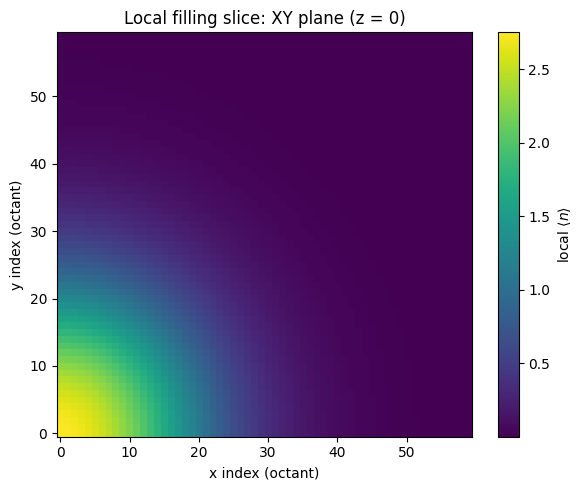

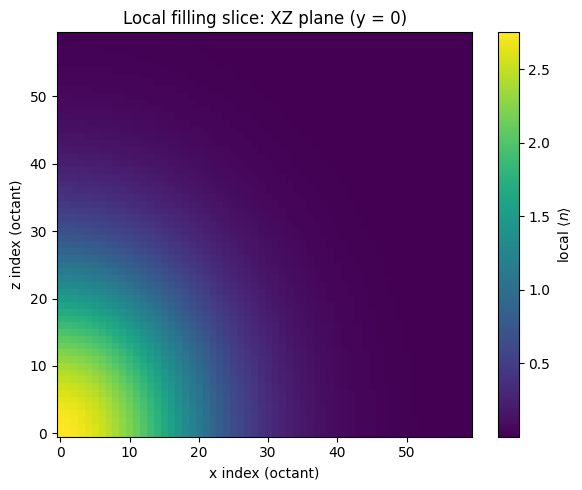

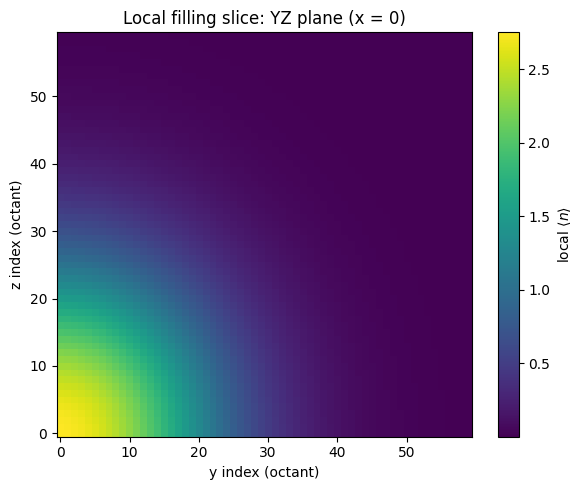

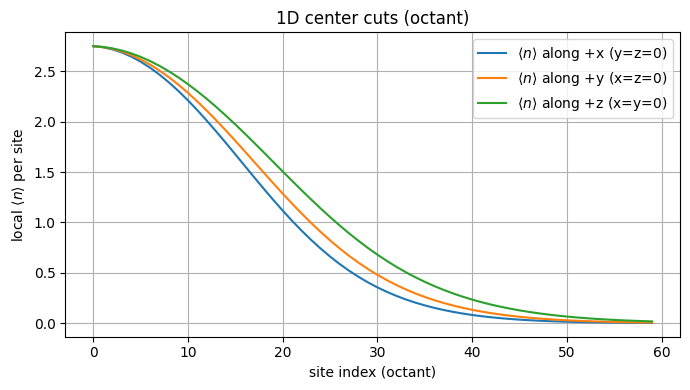

Ni min/max in octant: 4.67e-08 / 2.75

Gaussian+offset fits to 1D center cuts (effective sizes):
  sigma_x = 6.191 µm   (FWHM = 14.579 µm)
  sigma_y = 6.705 µm   (FWHM = 15.788 µm)
  sigma_z = 7.480 µm   (FWHM = 17.614 µm)


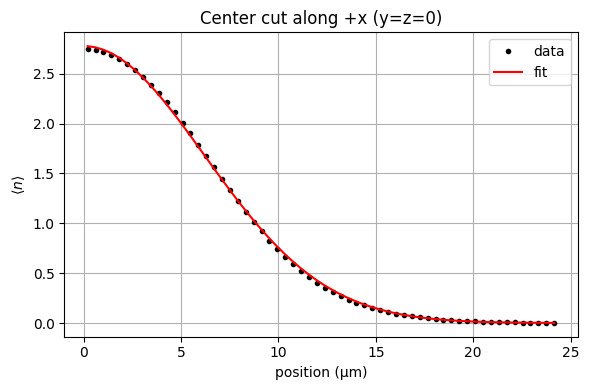

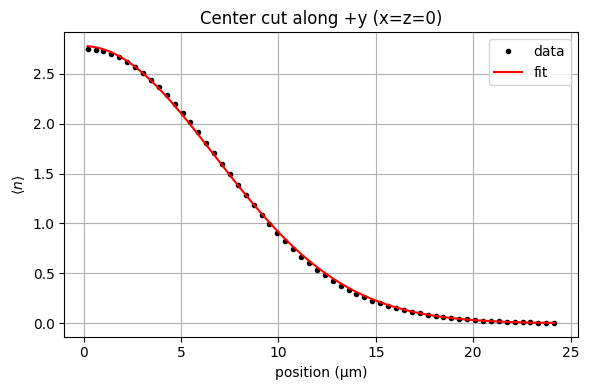

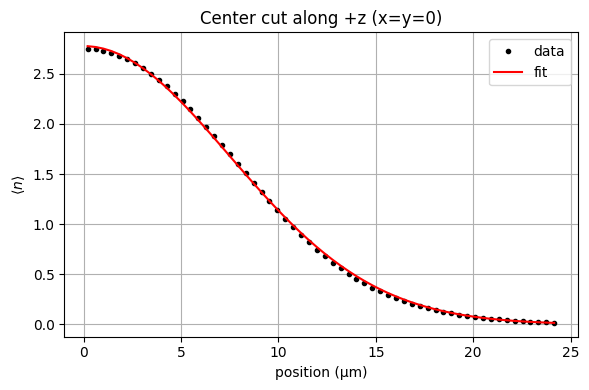

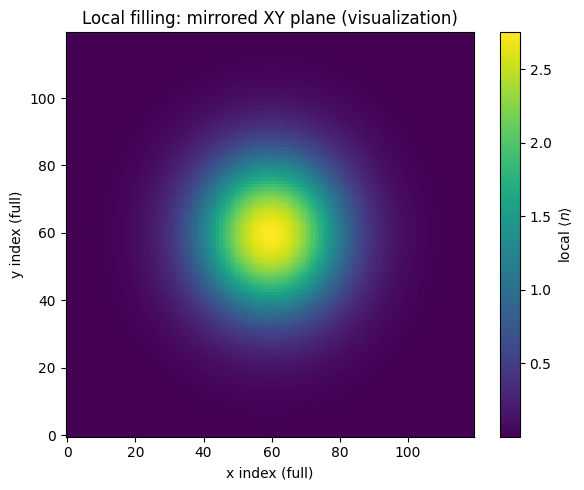

In [ ]:
# Atomic-limit Bose–Hubbard in an anisotropic harmonic trap
# Octant lattice-site sum (no spherical symmetry), with entropy constraint
# Fast implementation (no giant 4D arrays), plus:
#   - central filling <n>(0,0,0)
#   - 2D slices in XY (z=0), XZ (y=0), YZ (x=0)
#   - 1D cuts along x,y,z through the center

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.optimize import curve_fit


# -----------------------------
# Physical constants (SI)
# -----------------------------
hbar = 1.055e-34
kB   = 1.380649e-23
m    = 87 * 1.67e-27

lam = 812e-9
k = 2.0 * np.pi / lam
Er = hbar**2 * k**2 / (2 * m)          # recoil energy [J]
d  = lam / 2                            # lattice spacing [m]

# -----------------------------
# USER INPUTS
# -----------------------------
# Trap frequencies in the lattice at s=10 (TOTAL including lattice curvature), in Hz
# fx, fy, fz = 75 , 57.6 , 47           # 1700 mW final
fx, fy, fz = 83.8, 77.4, 69.4            # 950 mw  final
# fx, fy, fz = 66.4, 59.7, 56.6            # 830 mw  final



wx, wy, wz = 2*np.pi*fx, 2*np.pi*fy, 2*np.pi*fz

# Bose-Hubbard parameters
U_over_Er = 0.23                        # <-- replace if needed
U = U_over_Er * Er                      # [J]
nmax = 25                               # onsite occupation cutoff

# Targets
N_target = 200_000                       # total atom number
s_target = 1.8                          # entropy per particle in units of kB: s = S/(N kB)

# Grid / truncation controls
# We auto-pick grid size so edges are deep in vacuum; you can override with n_grid_override
n_grid_override = 60                  # set to an int (e.g. 60) to force size
eps_over_kBT_edge = 25.0                # heuristic: require eps_corner/(kBT) ~ 25 at guess T
n_grid_min, n_grid_max = 20, 140

# Initial guesses for solver
T_guess_nK = 100.0
z_guess    = 5.0

# -----------------------------
# Helpers: grid and fast atomic sums
# -----------------------------
def choose_n_grid(wx, wy, wz, T_guess, eps_over_kBT_edge=25.0,
                  n_grid_min=20, n_grid_max=140):
    """
    Pick n_grid so the octant corner has trap energy eps ~ eps_over_kBT_edge * kB*T_guess.
    This avoids wasting time summing lots of vacuum.
    """
    w2sum = wx**2 + wy**2 + wz**2
    if w2sum <= 0:
        return n_grid_min
    # eps_corner ~ 0.5*m*w2sum*(n d)^2
    n_est = np.sqrt((2 * eps_over_kBT_edge * kB * T_guess) / (m * w2sum)) / d
    n_grid = int(np.clip(np.ceil(n_est), n_grid_min, n_grid_max))
    return n_grid

def make_octant_eps(n_grid, wx, wy, wz):
    """
    Octant lattice sites i,j,k = 0..n_grid-1, shifted by +0.5 to avoid double-counting planes.
    eps(x,y,z) = 0.5 m (wx^2 x^2 + wy^2 y^2 + wz^2 z^2)  [J]
    """
    idx = (np.arange(n_grid, dtype=np.float64) + 0.5)
    X, Y, Z = np.meshgrid(idx, idx, idx, indexing='ij')
    x = X * d
    y = Y * d
    z = Z * d
    eps = 0.5 * m * (wx**2 * x**2 + wy**2 * y**2 + wz**2 * z**2)
    return eps

def atomic_octant_fast(T, z_fug, eps, U, nmax=10, octant_factor=8.0, return_fields=False):
    """
    Atomic-limit (t=0) grand-canonical on each site with fugacity z = exp(mu0/kBT).

    Weight at a site for occupancy n:
      w_n = exp( n ln z - beta*( n eps + U/2 n(n-1) ) )

    Uses per-site log-sum-exp across n without building (nmax+1, n, n, n) arrays.

    Returns full-space totals (octant_factor * sum_octant):
      Ntot, Stot_over_kB, dfrac (atoms in n>=2 weighted by n), n_center
    Optionally returns Ni (local <n>) too.
    """
    beta = 1.0 / (kB * T)
    lnz  = np.log(z_fug)
    mu0  = kB * T * lnz

    # log-sum-exp accumulators across n at each site
    amax = -np.inf * np.ones_like(eps, dtype=np.float64)
    sumexp = np.zeros_like(eps, dtype=np.float64)

    for n in range(nmax + 1):
        a_n = n * lnz - beta * (n * eps + 0.5 * U * n * (n - 1))
        new_amax = np.maximum(amax, a_n)
        sumexp = sumexp * np.exp(amax - new_amax) + np.exp(a_n - new_amax)
        amax = new_amax

    inv_sumexp = 1.0 / (sumexp + 1e-300)

    Ni = np.zeros_like(eps, dtype=np.float64)
    Egc = np.zeros_like(eps, dtype=np.float64)        # <E - mu n> per site
    atoms_in_nge2 = np.zeros_like(eps, dtype=np.float64)

    for n in range(nmax + 1):
        a_n = n * lnz - beta * (n * eps + 0.5 * U * n * (n - 1))
        p_n = np.exp(a_n - amax) * inv_sumexp

        Ni += n * p_n

        Egn = 0.5 * U * n * (n - 1) + n * eps - n * mu0  # (E - mu n)
        Egc += Egn * p_n

        if n >= 2:
            atoms_in_nge2 += n * p_n

    # entropy per site: S/kB = lnZ + beta * <E - mu n>
    lnZ = amax + np.log(sumexp + 1e-300)
    Si_over_kB = lnZ + beta * Egc

    Ntot = octant_factor * np.sum(Ni)
    Stot_over_kB = octant_factor * np.sum(Si_over_kB)

    dfrac = (octant_factor * np.sum(atoms_in_nge2)) / (Ntot + 1e-300)
    n_center = Ni[0, 0, 0]

    if return_fields:
        return Ntot, Stot_over_kB, dfrac, n_center, Ni, Si_over_kB
    return Ntot, Stot_over_kB, dfrac, n_center

def solve_T_z(N_target, s_target, eps, U, nmax=10,
              T_guess_nK=25.0, z_guess=5.0):
    """
    Solve for T and fugacity z such that:
      N(T,z) = N_target
      S(T,z)/(N kB) = s_target
    Solve in (logT, logz) for positivity.
    """
    def F(x):
        logT, logz = x
        T = np.exp(logT)
        zf = np.exp(logz)
        Ntot, Stot_over_kB, dfrac, n_center = atomic_octant_fast(T, zf, eps, U, nmax=nmax)
        s = Stot_over_kB / (Ntot + 1e-300)
        return np.array([Ntot - N_target, s - s_target], dtype=np.float64)

    x0 = np.array([np.log(T_guess_nK * 1e-9), np.log(z_guess)], dtype=np.float64)
    sol = root(F, x0, method='hybr')
    T_sol = np.exp(sol.x[0])
    z_sol = np.exp(sol.x[1])
    return T_sol, z_sol, sol

# -----------------------------
# Run
# -----------------------------
T_guess = T_guess_nK * 1e-9

if n_grid_override is None:
    n_grid = choose_n_grid(wx, wy, wz, T_guess,
                           eps_over_kBT_edge=eps_over_kBT_edge,
                           n_grid_min=n_grid_min, n_grid_max=n_grid_max)
else:
    n_grid = int(n_grid_override)

print(f"Octant grid n_grid={n_grid}  (octant sites = {n_grid**3:,})")

eps = make_octant_eps(n_grid, wx, wy, wz)

T_sol, z_sol, sol = solve_T_z(N_target, s_target, eps, U, nmax=nmax,
                              T_guess_nK=T_guess_nK, z_guess=z_guess)

print(f"Solve success: {sol.success} | {sol.message}")
print(f"T = {T_sol*1e9:.3f} nK")
print(f"z = {z_sol:.5g}")
mu0 = kB * T_sol * np.log(z_sol)
print(f"mu0/Er = {mu0/Er:.5f}")

Ntot, Stot_over_kB, dfrac, n_center, Ni, Si_over_kB = atomic_octant_fast(
    T_sol, z_sol, eps, U, nmax=nmax, return_fields=True
)

print(f"Ntot = {Ntot:.0f}")
print(f"S/N = {Stot_over_kB/Ntot:.3f} kB")
print(f"Central filling <n>(0,0,0) = {n_center:.3f}")
print(f"Atom fraction in n>=2 sites (weighted by n) = {dfrac:.3f}")

# -----------------------------
# REQUIRED OUTPUTS: 2D slices in 3 planes + central value + 1D cuts
# -----------------------------

# 2D slices through the "center" of the octant (closest-to-center site index = 0)
# XY plane at z=0
plt.figure(figsize=(6,5))
plt.imshow(Ni[:,:,0].T, origin='lower', aspect='auto')
plt.colorbar(label=r'local $\langle n\rangle$')
plt.title('Local filling slice: XY plane (z = 0)')
plt.xlabel('x index (octant)')
plt.ylabel('y index (octant)')
plt.tight_layout()
plt.show()

# XZ plane at y=0
plt.figure(figsize=(6,5))
plt.imshow(Ni[:,0,:].T, origin='lower', aspect='auto')
plt.colorbar(label=r'local $\langle n\rangle$')
plt.title('Local filling slice: XZ plane (y = 0)')
plt.xlabel('x index (octant)')
plt.ylabel('z index (octant)')
plt.tight_layout()
plt.show()

# YZ plane at x=0
plt.figure(figsize=(6,5))
plt.imshow(Ni[0,:,:].T, origin='lower', aspect='auto')
plt.colorbar(label=r'local $\langle n\rangle$')
plt.title('Local filling slice: YZ plane (x = 0)')
plt.xlabel('y index (octant)')
plt.ylabel('z index (octant)')
plt.tight_layout()
plt.show()

# 1D cuts through the center site along the three axes
plt.figure(figsize=(7,4))
plt.plot(Ni[:,0,0], label=r'$\langle n\rangle$ along +x (y=z=0)')
plt.plot(Ni[0,:,0], label=r'$\langle n\rangle$ along +y (x=z=0)')
plt.plot(Ni[0,0,:], label=r'$\langle n\rangle$ along +z (x=y=0)')
plt.xlabel('site index (octant)')
plt.ylabel(r'local $\langle n\rangle$ per site')
plt.title('1D center cuts (octant)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print a quick sanity range
print(f"Ni min/max in octant: {Ni.min():.3g} / {Ni.max():.3g}")

# -----------------------------
# Gaussian fits to 1D center cuts
# -----------------------------
def gauss_offset(x, A, sigma, C):
    # centered at x=0
    return A * np.exp(-(x**2) / (2*sigma**2)) + C

def fit_gaussian_cut(y, d, frac_peak=0.2):
    """
    Fit y(i) vs x(i) with a centered Gaussian + offset.
    Uses only points with y > C_guess + frac_peak*(max-C_guess) to avoid vacuum tail dominating.
    Returns sigma [um], FWHM [um], params, cov.
    """
    i = np.arange(len(y), dtype=np.float64)
    x = (i + 0.5) * d                # meters, center of first lattice site is at 0.5 d
    x_um = x * 1e6

    y = np.asarray(y, dtype=np.float64)

    # crude offset guess: tail median (last 20% of points)
    tail = y[int(0.8*len(y)):] if len(y) > 10 else y[-3:]
    C0 = float(np.median(tail))
    A0 = float(np.max(y) - C0)

    # sigma guess: where it drops to exp(-1/2) ~ 0.607 of peak above offset
    target = C0 + 0.607 * A0
    idx = np.where(y <= target)[0]
    if len(idx) > 0 and idx[0] > 0:
        sigma0 = float(x_um[idx[0]] / 1.0)  # because exp(-x^2/2σ^2)=0.607 at x=σ
    else:
        sigma0 = float(x_um[len(y)//5]) if len(y) > 5 else float(x_um[-1]/2)

    # select fit region to avoid vacuum tail driving crazy offsets
    thresh = C0 + frac_peak * max(A0, 1e-12)
    mask = y > thresh
    # always include at least a few points
    if np.sum(mask) < 6:
        mask[:min(12, len(y))] = True

    x_fit = x_um[mask]
    y_fit = y[mask]

    # bounds: A>=0, sigma>0, C free-ish but keep sane
    bounds = ([0.0, 0.05, 0.0], [np.inf, np.inf, np.inf])

    popt, pcov = curve_fit(
        gauss_offset, x_fit, y_fit,
        p0=[A0, sigma0, C0],
        bounds=bounds,
        maxfev=20000
    )

    A, sigma_um, C = popt
    fwhm_um = 2*np.sqrt(2*np.log(2)) * sigma_um
    return sigma_um, fwhm_um, popt, pcov

# Grab the three 1D cuts (octant)
cut_x = Ni[:, 0, 0]
cut_y = Ni[0, :, 0]
cut_z = Ni[0, 0, :]

sx, fwhmx, px, _ = fit_gaussian_cut(cut_x, d)
sy, fwhmy, py, _ = fit_gaussian_cut(cut_y, d)
sz, fwhmz, pz, _ = fit_gaussian_cut(cut_z, d)

print("\nGaussian+offset fits to 1D center cuts (effective sizes):")
print(f"  sigma_x = {sx:.3f} µm   (FWHM = {fwhmx:.3f} µm)")
print(f"  sigma_y = {sy:.3f} µm   (FWHM = {fwhmy:.3f} µm)")
print(f"  sigma_z = {sz:.3f} µm   (FWHM = {fwhmz:.3f} µm)")

# Plot fits over the raw cuts (optional but recommended)
def plot_cut_with_fit(y, d, popt, title):
    i = np.arange(len(y), dtype=np.float64)
    x_um = (i + 0.5) * d * 1e6
    plt.figure(figsize=(6,4))
    plt.plot(x_um, y, 'k.', label='data')
    plt.plot(x_um, gauss_offset(x_um, *popt), 'r-', label='fit')
    plt.xlabel('position (µm)')
    plt.ylabel(r'$\langle n\rangle$')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_cut_with_fit(cut_x, d, px, 'Center cut along +x (y=z=0)')
plot_cut_with_fit(cut_y, d, py, 'Center cut along +y (x=z=0)')
plot_cut_with_fit(cut_z, d, pz, 'Center cut along +z (x=y=0)')


# -----------------------------
# (Optional) Mirror local 2D slice to visualize full-plane anisotropy
# This is purely for visualization; local physics is in Ni.
# -----------------------------
def mirror_2d_to_full(A):
    # A is octant-plane array shape (n_grid, n_grid)
    return np.block([
        [np.flip(np.flip(A, axis=0), axis=1), np.flip(A, axis=0)],
        [np.flip(A, axis=1),                 A]
    ])

xy_full = mirror_2d_to_full(Ni[:,:,0])
plt.figure(figsize=(6,5))
plt.imshow(xy_full.T, origin='lower', aspect='auto')
plt.colorbar(label=r'local $\langle n\rangle$')
plt.title('Local filling: mirrored XY plane (visualization)')
plt.xlabel('x index (full)')
plt.ylabel('y index (full)')
plt.tight_layout()
plt.show()